In [1]:
"""
RF Amplitude Scan (Radial Confinement)
=========================================
Produces:
  - Figure 3.8: Ion count rate vs. RF amplitude (V_RF) at 1144 kHz
  - Figure 3.9: Ion count rate vs. Mathieu q-value at 1144 kHz, assuming a
    rubidium mass (the working assumption for the dominant species in the
    mixed alkali source)
  - Presentation figure (not numbered in the dissertation): the same scan
    annotated with each candidate species' predicted q=0.8 stability
    dropout voltage

1144 kHz, with DC gradient (ΔV=10V), was the drive frequency selected for
the RFQ's radial (transverse) confinement after testing several
alternatives (§3.4.3).
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import glob
import re

e = 1.602176634e-19    # elementary charge, C
u = 1.66053906660e-27  # atomic mass unit, kg

potassium_mass = 39.0983    # g/mol
rubidium_mass = 85.4678     # g/mol
cesium_mass = 132.90545     # g/mol

vpp_frac_err = 0.125  # established RF probe/divider systematic error (§3.4.3)

In [2]:
# Effective field radius r0,eff: derived from measured board-gap separations
# along two axes (accounting for slight rectangular asymmetry in the
# assembled stack), corrected by the 1.08 field-penetration factor for the
# PCB electrode design. This is the canonical source of r0,eff used
# throughout this work -- other notebooks referencing r0=0.00505 m are
# using a rounded copy of this value.
r_0 = 1/2 * np.sqrt((0.5 * (6.60 + 6.55))**2 + (0.5 * (6.60 + 6.72))**2) * 1.08
print(f"r0,eff = {r_0:.3f} mm")


def q_val(mass_u, freq_khz, r0_mm, vpp):
    """Mathieu q-value, q = 2*e*Vpp / (m * Omega^2 * r0^2)."""
    m_kg = mass_u * u
    V0 = vpp / 2
    omega = 2 * np.pi * freq_khz * 1e3
    r0_m = r0_mm / 1000
    return 4 * e * V0 / (m_kg * omega**2 * r0_m**2)

r0,eff = 5.054 mm


In [3]:
def parse_rf_filename(filepath):
    basename = filepath.split("/")[-1]
    match = re.match(r"RF(\d+)_(\d+)(?:_(\d+))?\.mpa$", basename)
    if match is None:
        return None
    vpp = int(match.group(1))
    freq_khz = int(match.group(2))
    run = int(match.group(3)) if match.group(3) else 1
    return vpp, freq_khz, run


def read_mpa_file(filepath):
    """Parses REALTIME and TOTALSUM from an MPANT ASCII export."""
    realtime = None
    totalsum = None
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())
    return realtime, totalsum


def get_rate_and_uncertainty(filepath):
    realtime, totalsum = read_mpa_file(filepath)
    if realtime is None or totalsum is None:
        print(f"WARNING: couldn't parse REALTIME/TOTALSUM from {filepath}, skipping")
        return None, None
    rate = totalsum / realtime
    rate_unc = np.sqrt(totalsum) / realtime
    return rate, rate_unc


rf_files = [f for f in glob.glob("RFPCB/RF*.mpa") if "Noise" not in f]

rf_runs = []
for filepath in rf_files:
    parsed = parse_rf_filename(filepath)
    if parsed is None:
        continue
    vpp, freq_khz, run = parsed
    rf_runs.append({"filepath": filepath, "vpp": vpp, "freq_khz": freq_khz, "run": run})

rf_runs_df = pd.DataFrame(rf_runs).sort_values(["freq_khz", "vpp", "run"]).reset_index(drop=True)

rf_runs_df["rate_hz"], rf_runs_df["rate_unc_hz"] = zip(
    *rf_runs_df["filepath"].apply(get_rate_and_uncertainty)
)

In [4]:
"""
Final RF amplitude scan (previously "Run 12"): 1144 kHz, with DC gradient
(ΔV=10V). Earlier frequency/config comparisons (Runs 1-11, 13) were
preliminary and are not included here.
"""

rf_amplitude_scan = rf_runs_df[rf_runs_df["run"] == 12].copy().sort_values("vpp")
rf_amplitude_scan

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz
171,RFPCB/RF4_1144_12.mpa,4,1144,12,8.056565,0.283254
173,RFPCB/RF25_1144_12.mpa,25,1144,12,12.634100,0.355081
175,RFPCB/RF50_1144_12.mpa,50,1144,12,6.783787,0.260146
177,RFPCB/RF68_1144_12.mpa,68,1144,12,41.655840,0.645226
179,RFPCB/RF88_1144_12.mpa,88,1144,12,41.876968,0.646946
181,RFPCB/RF102_1144_12.mpa,102,1144,12,58.187913,0.761946
183,RFPCB/RF126_1144_12.mpa,126,1144,12,55.578809,0.744233
185,RFPCB/RF150_1144_12.mpa,150,1144,12,73.756945,0.856944
187,RFPCB/RF170_1144_12.mpa,170,1144,12,80.850851,0.898565
189,RFPCB/RF184_1144_12.mpa,184,1144,12,89.661436,0.946008


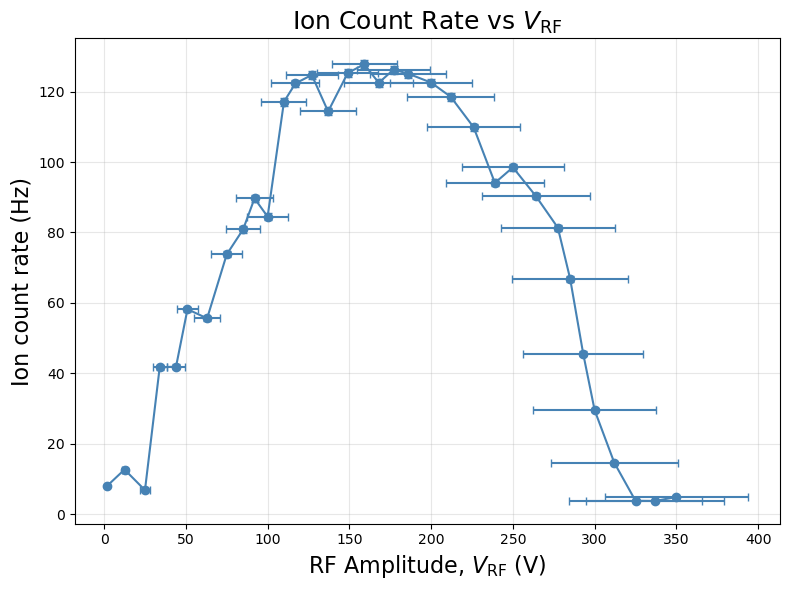

In [5]:
"""
Figure 3.8: Ion Count Rate vs. RF Amplitude (V_RF)
--------------------------------------------------------
"""

v_rf = rf_amplitude_scan["vpp"] / 2
v_rf_xerr = v_rf * vpp_frac_err

plt.figure(figsize=(8, 6))
plt.errorbar(
    v_rf, rf_amplitude_scan["rate_hz"],
    yerr=rf_amplitude_scan["rate_unc_hz"], xerr=v_rf_xerr,
    marker="o", capsize=3, color="steelblue"
)
plt.xlabel(r"RF Amplitude, $V_{\mathrm{RF}}$ (V)", fontsize=16)
plt.ylabel("Ion count rate (Hz)", fontsize=16)
plt.title(r"Ion Count Rate vs $V_{\mathrm{RF}}$", fontsize=18)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

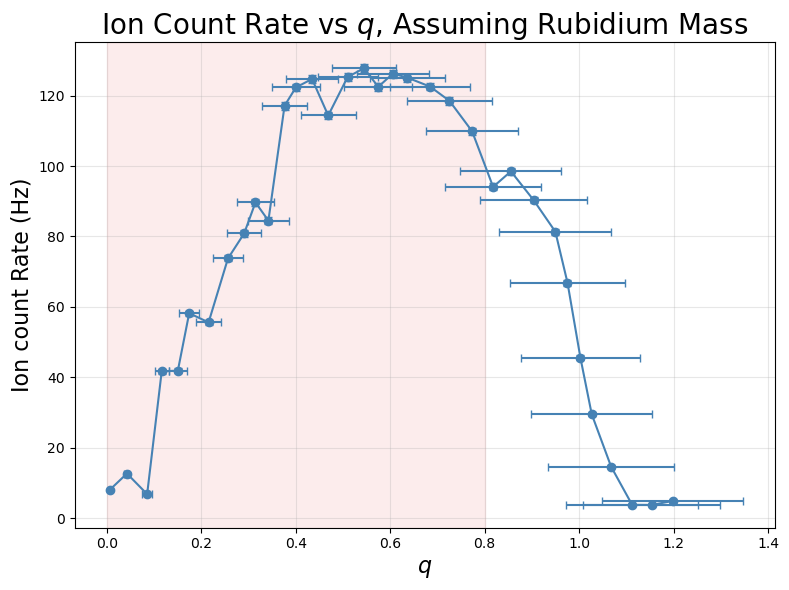

In [6]:
"""
Figure 3.9: Ion Count Rate vs. Mathieu q-value, Rubidium Mass Assumption
------------------------------------------------------------------------------
"""

rf_amplitude_scan["q"] = rf_amplitude_scan.apply(
    lambda row: q_val(rubidium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
)
rf_amplitude_scan = rf_amplitude_scan.sort_values("q")
q_xerr = rf_amplitude_scan["q"] * vpp_frac_err

fig, ax = plt.subplots(figsize=(8, 6))
ax.axvspan(0, 0.8, color='lightcoral', alpha=0.15)
ax.errorbar(
    rf_amplitude_scan["q"], rf_amplitude_scan["rate_hz"],
    yerr=rf_amplitude_scan["rate_unc_hz"], xerr=q_xerr,
    marker="o", capsize=3, color="steelblue"
)
ax.set_xlabel("$q$", fontsize=16)
ax.set_ylabel("Ion count Rate (Hz)", fontsize=16)
ax.set_title("Ion Count Rate vs $q$, Assuming Rubidium Mass", fontsize=20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
def vrf_for_q(mass_u, freq_hz, q_target, r0_m, pot_eff=1.0):
    """Inverse of q_val: given a target q, find the V_RF (zero-to-peak) that produces it."""
    m_kg = mass_u * u
    omega = 2 * np.pi * freq_hz
    return q_target * m_kg * r0_m**2 * omega**2 / (4 * e)


freq_khz = 1144
operating_v_rf = 155  # V_RF used for transmission tests

species_boundaries = {
    "Potassium": {"mass": potassium_mass, "color": "tab:red"},
    "Rubidium": {"mass": rubidium_mass, "color": "tab:orange"},
    "Cesium": {"mass": cesium_mass, "color": "tab:blue"},
}

for name, cfg in species_boundaries.items():
    cfg["v_rf_boundary"] = vrf_for_q(cfg["mass"], freq_khz * 1000, 0.8, r_0 / 1000)

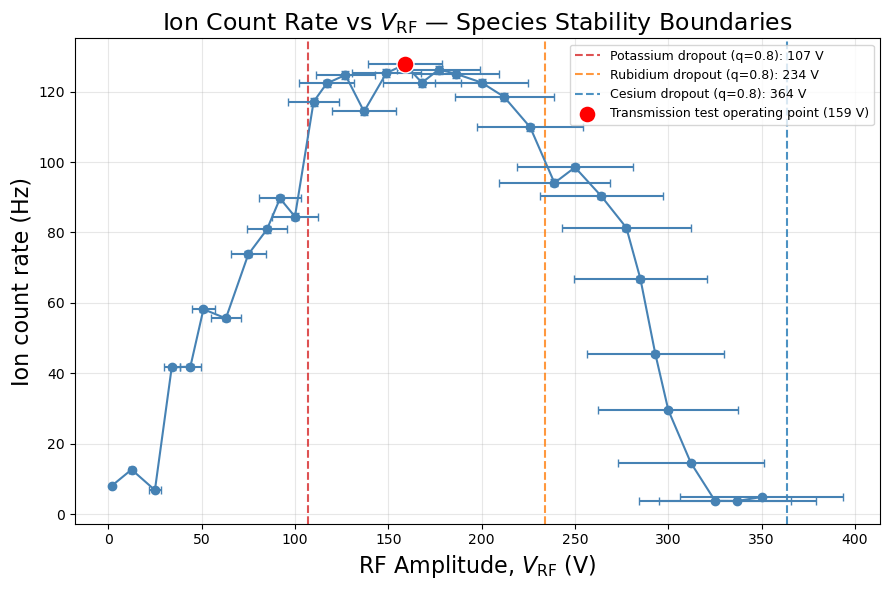

In [8]:
"""
Presentation figure (not a numbered dissertation figure): same scan as
Figures 3.8/3.9, annotated with each species' predicted q=0.8 stability
dropout voltage and the actual RF amplitude used for transmission tests.
"""

plot_df = rf_amplitude_scan.sort_values("vpp")
v_rf = plot_df["vpp"] / 2
v_rf_xerr = v_rf * vpp_frac_err

plt.figure(figsize=(9, 6))
plt.errorbar(
    v_rf, plot_df["rate_hz"],
    yerr=plot_df["rate_unc_hz"], xerr=v_rf_xerr,
    marker="o", capsize=3, color="steelblue", zorder=5
)

for name, cfg in species_boundaries.items():
    plt.axvline(cfg["v_rf_boundary"], color=cfg["color"], linestyle="--", alpha=0.8,
                label=f"{name} dropout (q=0.8): {cfg['v_rf_boundary']:.0f} V")

closest_idx = (v_rf - operating_v_rf).abs().idxmin()
plt.scatter(v_rf.loc[closest_idx], plot_df.loc[closest_idx, "rate_hz"],
            marker="o", s=150, color="red", edgecolor="white", linewidth=1, zorder=6,
            label=f"Transmission test operating point ({v_rf.loc[closest_idx]:.0f} V)")

plt.xlabel(r"RF Amplitude, $V_{\mathrm{RF}}$ (V)", fontsize=16)
plt.ylabel("Ion count rate (Hz)", fontsize=16)
plt.title(r"Ion Count Rate vs $V_{\mathrm{RF}}$ — Species Stability Boundaries", fontsize=17)
plt.legend(fontsize=9)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
import os
import shutil

def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)

def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw/, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)

    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)

    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing

In [10]:
description = [
    "Ion Count Rate vs. RF Amplitude (V_RF) and Mathieu q-value",
    "Corresponds to Figures 3.8 and 3.9",
    "",
    "Purpose: characterizes radial (transverse) ion confinement provided by",
    "the RFQ's RF field, following axial confinement characterization",
    "(Figure 3.7). RF amplitude directly sets the strength of the radial",
    "confining pseudopotential; too little confinement loses ions radially,",
    "while too much can destabilize ion motion via collisional RF heating.",
    "1144 kHz was selected as the drive frequency after testing several",
    "alternatives (Section 3.4.3).",
    "",
    "The Mathieu q-value reinterprets the same scan in terms of the",
    "dimensionless stability parameter that actually governs confinement,",
    "computed assuming a rubidium mass (the working assumption for the",
    "dominant species in the mixed alkali source), via",
    "q = 2*e*Vpp / (m * r0^2 * Omega^2).",
    "",
    "V_RF carries a systematic uncertainty of ~12.5% from probe and",
    "voltage-divider calibration on the driver box, applied as a single",
    "shared offset across all points from a given run; this propagates",
    "directly into the q uncertainty.",
    "",
    "Columns:",
    "  v_rf_volts    - RF amplitude, zero-to-peak (V) = Vpp/2",
    "  v_rf_err_volts- Uncertainty on V_RF (12.5% probe/divider systematic)",
    "  q             - Mathieu q-value (rubidium mass assumption)",
    "  q_err         - Uncertainty on q (from the same 12.5% systematic)",
    "  rate_hz       - Ion count rate (Hz)",
    "  rate_unc_hz   - Ion count rate uncertainty (Hz)",
    "  file          - Source .mpa filename",
]

rf_amplitude_scan["v_rf"] = rf_amplitude_scan["vpp"] / 2
rf_amplitude_scan["v_rf_err"] = rf_amplitude_scan["v_rf"] * vpp_frac_err
rf_amplitude_scan["q_err"] = rf_amplitude_scan["q"] * vpp_frac_err

export_cols_map = {
    "v_rf": "v_rf_volts",
    "v_rf_err": "v_rf_err_volts",
    "q": "q",
    "q_err": "q_err",
    "rate_hz": "rate_hz",
    "rate_unc_hz": "rate_unc_hz",
    "filepath": "file",
}

export_df = rf_amplitude_scan[list(export_cols_map.keys())].rename(columns=export_cols_map)
export_df = export_df.sort_values("v_rf_volts").reset_index(drop=True)

export_figure_csv(export_df, "thesis/rf_amplitude_and_q_value.csv", description)
print(export_df)

archive_raw_files(export_df["file"].str.split("/").str[-1].tolist(), "RFPCB", "rf_amplitude_and_q_value")

    v_rf_volts  v_rf_err_volts         q     q_err     rate_hz  rate_unc_hz  \
0          2.0          0.2500  0.006844  0.000856    8.056565     0.283254   
1         12.5          1.5625  0.042775  0.005347   12.634100     0.355081   
2         25.0          3.1250  0.085551  0.010694    6.783787     0.260146   
3         34.0          4.2500  0.116349  0.014544   41.655840     0.645226   
4         44.0          5.5000  0.150569  0.018821   41.876968     0.646946   
5         51.0          6.3750  0.174523  0.021815   58.187913     0.761946   
6         63.0          7.8750  0.215588  0.026948   55.578809     0.744233   
7         75.0          9.3750  0.256652  0.032082   73.756945     0.856944   
8         85.0         10.6250  0.290872  0.036359   80.850851     0.898565   
9         92.0         11.5000  0.314827  0.039353   89.661436     0.946008   
10       100.0         12.5000  0.342203  0.042775   84.487824     0.917317   
11       110.0         13.7500  0.376423  0.047053  

(['RF4_1144_12.mpa',
  'RF25_1144_12.mpa',
  'RF50_1144_12.mpa',
  'RF68_1144_12.mpa',
  'RF88_1144_12.mpa',
  'RF102_1144_12.mpa',
  'RF126_1144_12.mpa',
  'RF150_1144_12.mpa',
  'RF170_1144_12.mpa',
  'RF184_1144_12.mpa',
  'RF200_1144_12.mpa',
  'RF220_1144_12.mpa',
  'RF234_1144_12.mpa',
  'RF254_1144_12.mpa',
  'RF274_1144_12.mpa',
  'RF298_1144_12.mpa',
  'RF318_1144_12.mpa',
  'RF336_1144_12.mpa',
  'RF354_1144_12.mpa',
  'RF372_1144_12.mpa',
  'RF400_1144_12.mpa',
  'RF424_1144_12.mpa',
  'RF452_1144_12.mpa',
  'RF478_1144_12.mpa',
  'RF500_1144_12.mpa',
  'RF528_1144_12.mpa',
  'RF555_1144_12.mpa',
  'RF570_1144_12.mpa',
  'RF586_1144_12.mpa',
  'RF600_1144_12.mpa',
  'RF624_1144_12.mpa',
  'RF650_1144_12.mpa',
  'RF674_1144_12.mpa',
  'RF700_1144_12.mpa'],
 [])

In [11]:
description = [
    "Ion Count Rate vs. RF Amplitude, with Species Stability Boundaries",
    "Presentation figure (not a numbered dissertation figure)",
    "",
    "Purpose: same RF amplitude scan as Figures 3.8/3.9, annotated with the",
    "predicted q=0.8 stability dropout voltage for each candidate source",
    "species (potassium, rubidium, cesium), computed by inverting the Mathieu",
    "q relation for each species' mass at the same RF frequency (1144 kHz).",
    "This shows where each species would be expected to destabilize and lose",
    "confinement, and highlights the actual RF amplitude used for the",
    "transmission efficiency measurements (~155 V_RF).",
    "",
    "Columns:",
    "  v_rf_volts     - RF amplitude, zero-to-peak (V), measured scan point",
    "  v_rf_err_volts - Uncertainty on V_RF (12.5% probe/divider systematic)",
    "  rate_hz        - Ion count rate (Hz)",
    "  rate_unc_hz    - Ion count rate uncertainty (Hz)",
    "  file           - Source .mpa filename",
    "",
    "Derived species stability boundaries (q=0.8 dropout point, at 1144 kHz):",
    f"  Potassium: {species_boundaries['Potassium']['v_rf_boundary']:.1f} V",
    f"  Rubidium:  {species_boundaries['Rubidium']['v_rf_boundary']:.1f} V",
    f"  Cesium:    {species_boundaries['Cesium']['v_rf_boundary']:.1f} V",
    "  Operating point used for transmission tests: ~155 V",
]

export_df_pres = rf_amplitude_scan[["v_rf", "v_rf_err", "rate_hz", "rate_unc_hz", "filepath"]].rename(
    columns={"v_rf": "v_rf_volts", "v_rf_err": "v_rf_err_volts", "filepath": "file"}
).sort_values("v_rf_volts").reset_index(drop=True)

export_figure_csv(export_df_pres, "thesis/rf_amplitude_species_boundaries.csv", description)
print(export_df_pres)

    v_rf_volts  v_rf_err_volts     rate_hz  rate_unc_hz  \
0          2.0          0.2500    8.056565     0.283254   
1         12.5          1.5625   12.634100     0.355081   
2         25.0          3.1250    6.783787     0.260146   
3         34.0          4.2500   41.655840     0.645226   
4         44.0          5.5000   41.876968     0.646946   
5         51.0          6.3750   58.187913     0.761946   
6         63.0          7.8750   55.578809     0.744233   
7         75.0          9.3750   73.756945     0.856944   
8         85.0         10.6250   80.850851     0.898565   
9         92.0         11.5000   89.661436     0.946008   
10       100.0         12.5000   84.487824     0.917317   
11       110.0         13.7500  117.136464     1.081680   
12       117.0         14.6250  122.328336     1.104300   
13       127.0         15.8750  124.734337     1.115613   
14       137.0         17.1250  114.360959     1.068095   
15       149.0         18.6250  125.300652     1.118266 